# Implicit Neural Activation (INA) Playground 
- Comparisons between Siren, ReLU, GELU, SILU, and ZaiLU activations.

In [2]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, Dataset 
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import os 

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import skimage 

In [3]:
def get_mgrid(sidelen, dim=2):
    """Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    Args:
        sidelen: The length of the grid along each dimension.
        dim: The number of dimensions for the grid (default is 2).
    Returns:
        A tensor containing the flattened grid of coordinates.
    """
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

In [4]:
class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.
    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))
    
    def forward_with_intermediate(self, input): 
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate
    
    
class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, 
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, 
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, 
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, 
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)
                
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, 
                                      is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords        

    def forward_with_activations(self, coords, retain_grad=False):
        '''Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!'''
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations['input'] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)
                
                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()
                    
                activations['_'.join((str(layer.__class__), "%d" % activation_count))] = intermed
                activation_count += 1
            else: 
                x = layer(x)
                
                if retain_grad:
                    x.retain_grad()
                    
            activations['_'.join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations

In [5]:
def laplace(y, x):
    grad = gradient(y, x)
    return divergence(grad, x)


def divergence(y, x):
    div = 0.
    for i in range(y.shape[-1]):
        div += torch.autograd.grad(y[..., i], x, torch.ones_like(y[..., i]), create_graph=True)[0][..., i:i+1]
    return div


def gradient(y, x, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(y)
    grad = torch.autograd.grad(y, [x], grad_outputs=grad_outputs, create_graph=True)[0]
    return grad

def PSNR(x, y):
    mse = F.mse_loss(x, y)
    psnr = 10 * torch.log10(1 / mse)
    return psnr

torch.Size([1, 256, 256])
PSNR of noisy image: 20.00 dB


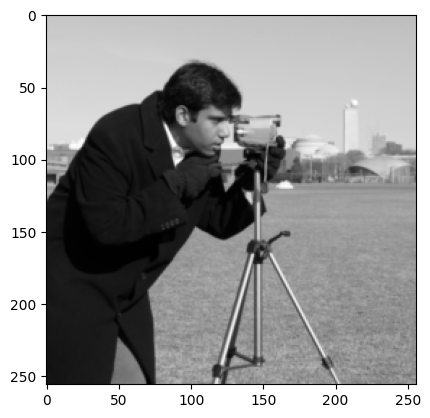

In [7]:
def get_cameraman_tensor(sidelength):
    img = Image.fromarray(skimage.data.camera())
    transform = Compose([
        Resize((sidelength, sidelength)), 
        ToTensor(),
        Normalize((0.5,), (0.5,))
    ])
    img = transform(img)
    return img

img = get_cameraman_tensor(256)
print(img.shape)

plt.imshow(img.squeeze().numpy(), cmap='gray')

img_noise = img + 0.1 * torch.randn_like(img)
psnr = PSNR(img, img_noise)
print(f"PSNR of noisy image: {psnr.item():.2f} dB")

In [17]:
class ImageFitting(Dataset):
    def __init__(self, sidelength):
        self.img = get_cameraman_tensor(sidelength)
        self.pixels = img.permute(1, 2, 0).reshape(-1, 1)
        self.coords = get_mgrid(sidelength)
    def __len__(self):
        return 1
    def __getitem__(self, idx):
        if idx > 0:
            raise IndexError("Dataset only contains one item.")
        return self.coords, self.pixels

In [ ]:
cameraman = ImageFitting(256)
dataloader = DataLoader(cameraman, batch_size=1, pin_memory=True) 

In [ ]:
def train(model, image, dataloader, device, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    
    total_steps = 500 
    steps_til_summary = 10 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    input, target = next(iter(dataloader))
    input, target = input.to(device), target.to(device)

    for step in range(total_steps):
        optimizer.zero_grad()
        output, coords = model(input)
        loss = F.mse_loss(output, target)
        loss.backward()
        optimizer.step()

        if step % steps_til_summary == 0:
            img_grad = gradient(output, coords)
            img_laplace = laplace(output, coords)
            
            psnr = PSNR(output, target)
            print(f"Step {step}: Loss = {loss.item():.6f}, PSNR = {psnr.item():.2f} dB")

            fig, axes = plt.subplots(1, 4, figsize=(18, 6))
            axes[0].imshow(target.detach().cpu().numpy().reshape(image.shape[1], image.shape[2]), cmap='gray')
            axes[1].imshow(output.detach().cpu().numpy().reshape(image.shape[1], image.shape[2]), cmap='gray')
            axes[2].imshow(img_grad.norm(dim=-1).detach().cpu().numpy().reshape(image.shape[1], image.shape[2]), cmap='gray')
            axes[3].imshow(img_laplace.detach().cpu().numpy().reshape(image.shape[1], image.shape[2]), cmap='gray')
        
            axes[0].set_title("Target Image")
            axes[1].set_title("Output Image")
            axes[2].set_title("Gradient Magnitude")
            axes[3].set_title("Laplacian")

            fig.suptitle(f"Step {step}: Loss = {loss.item():.6f}, PSNR = {psnr.item():.2f} dB")
            plt.savefig(f"{output_dir}/training_step_{step}.png")

## 1. Siren Model

In [ ]:
from typing import OrderedDict

class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.
    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))
    
    def forward_with_intermediate(self, input): 
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate
      
class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, 
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, 
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, 
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, 
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)
                
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, 
                                      is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords        

    def forward_with_activations(self, coords, retain_grad=False):
        '''Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!'''
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations['input'] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)
                
                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()
                    
                activations['_'.join((str(layer.__class__), "%d" % activation_count))] = intermed
                activation_count += 1
            else: 
                x = layer(x)
                
                if retain_grad:
                    x.retain_grad()
                    
            activations['_'.join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations


In [ ]:
model_siren = Siren(in_features=2, out_features=1, hidden_features=256, hidden_layers=3, outermost_linear=True).to("cuda")
train(model_siren, img, dataloader, device="cuda", output_dir="./siren/")

## 2. ReLU Model

In [ ]:
import sys
sys.path.append('..')

class INRLayer(nn.Module):
    """Generic layer for Implicit Neural Representations with any activation."""

    def __init__(self, in_features, out_features, activation_fn, bias=True, init='kaiming'):
        super().__init__()
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.activation = activation_fn
        self.init = init
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.init == 'kaiming':
                # He initialization — best for ReLU-like activations
                nn.init.kaiming_normal_(self.linear.weight, nonlinearity='relu')
            elif self.init == 'xavier':
                # Glorot initialization — good for smooth activations (GELU, ZiLU)
                nn.init.xavier_uniform_(self.linear.weight)
            if self.linear.bias is not None:
                nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return self.activation(self.linear(x))

    def forward_with_intermediate(self, x):
        intermediate = self.linear(x)
        return self.activation(intermediate), intermediate


class INR(nn.Module):
    """
    Generic Implicit Neural Representation model.
    Drop-in replacement for Siren that works with any activation function.
    """

    def __init__(self, in_features, hidden_features, hidden_layers, out_features,
                 activation_fn, outermost_linear=True, init='kaiming'):
        super().__init__()

        self.net = []
        self.net.append(INRLayer(in_features, hidden_features, activation_fn, init=init))

        for _ in range(hidden_layers):
            self.net.append(INRLayer(hidden_features, hidden_features, activation_fn, init=init))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            nn.init.xavier_uniform_(final_linear.weight)
            nn.init.zeros_(final_linear.bias)
            self.net.append(final_linear)
        else:
            self.net.append(INRLayer(hidden_features, out_features, activation_fn, init=init))

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True)
        output = self.net(coords)
        return output, coords

    def forward_with_activations(self, coords, retain_grad=False):
        activations = OrderedDict()
        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations['input'] = x

        for i, layer in enumerate(self.net):
            if isinstance(layer, INRLayer):
                x, intermed = layer.forward_with_intermediate(x)
                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()
                activations[f'{layer.__class__.__name__}_{activation_count}'] = intermed
                activation_count += 1
            else:
                x = layer(x)
                if retain_grad:
                    x.retain_grad()
            activations[f'{layer.__class__.__name__}_{activation_count}'] = x
            activation_count += 1

        return activations


# ---- ReLU Model ----
model_relu = INR(
    in_features=2, out_features=1,
    hidden_features=256, hidden_layers=3,
    activation_fn=nn.ReLU(),
    outermost_linear=True, init='kaiming'
).to("cuda")

train(model_relu, img, dataloader, device="cuda", output_dir="./relu/")

## 3. GELU Model

In [ ]:
model_gelu = INR(
    in_features=2, out_features=1,
    hidden_features=256, hidden_layers=3,
    activation_fn=nn.GELU(),
    outermost_linear=True, init='xavier'
).to("cuda")

train(model_gelu, img, dataloader, device="cuda", output_dir="./gelu/")

## 4. ZaiLU Model

In [ ]:
class ArcTan(nn.Module):
    def __init__(self, sigma=None):
        super(ArcTan, self).__init__()

        self.sigma = sigma if sigma else nn.Parameter(torch.tensor(5.0))

    def forward(self, x):
        return 0.5 + (1.0 / torch.pi) * torch.arctan(self.sigma * x)

class ZiLU(nn.Module):
    def __init__(self, sigma=None):
        super(ZiLU, self).__init__()
        self.arctan = ArcTan(sigma)
        
    def forward(self, x):
        return x * self.arctan(x)


In [ ]:
model_zailu = INR(
    in_features=2, out_features=1,
    hidden_features=256, hidden_layers=3,
    activation_fn=ZiLU(sigma=5.0),
    outermost_linear=True, init='xavier'
).to("cuda")

train(model_zailu, img, dataloader, device="cuda", output_dir="./zailu/")

## 5. ZaiLU Approx Model

In [ ]:
class ArcTan_Approx(nn.Module):
    def __init__(self, sigma=None):
        super(ArcTan_Approx, self).__init__()
        
        self.sigma = sigma if sigma else nn.Parameter(torch.tensor(5.0))

    def forward(self, x): 
        z = self.sigma * x 
        return (0.5 + torch.clamp(z, min=0)) / (1.0 + torch.abs(z))


class ZiLU_Approx(nn.Module):
    def __init__(self, sigma=None):
        super(ZiLU_Approx, self).__init__()
        self.arctan_approx = ArcTan_Approx(sigma)
        
    def forward(self, x):
        return x * self.arctan_approx(x)

In [ ]:
model_zailu_approx = INR(
    in_features=2, out_features=1,
    hidden_features=256, hidden_layers=3,
    activation_fn=ZiLU_Approx(sigma=5.0),
    outermost_linear=True, init='xavier'
).to("cuda")

train(model_zailu_approx, img, dataloader, device="cuda", output_dir="./zailu_approx/")